In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import model

# Experiment 1: Agent Parameters

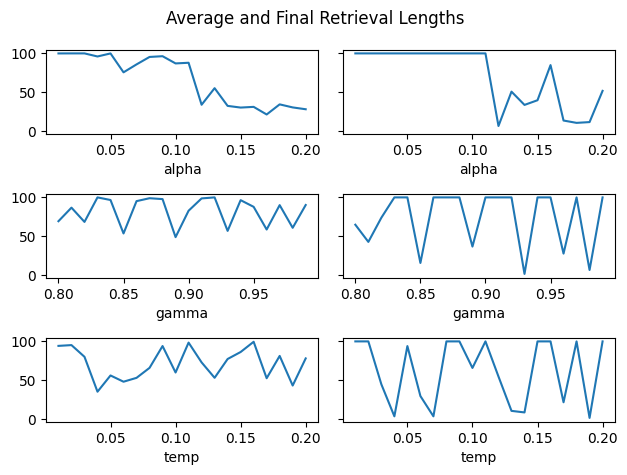

In [3]:
def calculate_data(opt, params, n):
    avg_retrieval = []
    final_retrieval = []
    for p in params:
        if opt == "alpha":
            agent = model.Agent(alpha=p)
        elif opt == "gamma":
            agent = model.Agent(gamma=p)
        elif opt == "temp":
            agent = model.Agent(temp=p)
        rewards = {i: 1 for i in range(100)}
        rewards[0] = -10
        environment = model.Memory(100, 20, 99, rewards)
        test = model.Simulator(agent, environment)
        test.run(n, 99, time=0.1)
        retrieval_length = [len(trial) for trial in test.record]
        avg_retrieval.append(np.mean(retrieval_length))
        final_retrieval.append(retrieval_length[-1])
    return avg_retrieval, final_retrieval
    
fig, axs = plt.subplots(3, 2, sharey=True)
alphas = [n / 100 for n in range (1, 21)]
gammas = [n / 100 for n in range(80, 100)]
temps = [n / 100 for n in range(1, 21)]
ax_count = 0
for opt, params in {"alpha": alphas, "gamma": gammas, "temp": temps}.items():
    avg_retrieval, final_retrieval = calculate_data(opt, params, 20)
    sns.lineplot(x=params, y=avg_retrieval, ax=axs[ax_count][0])
    sns.lineplot(x=params, y=final_retrieval, ax=axs[ax_count][1])
    axs[ax_count][0].set_xlabel(opt)
    axs[ax_count][1].set_xlabel(opt)
    ax_count += 1
fig.suptitle("Average and Final Retrieval Lengths")
plt.tight_layout()
plt.show()

# Experiment 2: Environment Parameters

In [29]:
def exp_2(n, groups, max_length, runs=100, time=0.1, rewards=None):
    agent = model.Agent()
    if rewards is None:
        rewards = {i: 1 for i in range(n)}
        rewards[0] = -10
    environment = model.Memory(n, groups, 99, rewards)
    test = model.Simulator(agent, environment)
    test.run(runs, max_length, time=time)
    retrieval_length = [len(trial) for trial in test.record]
    return retrieval_length

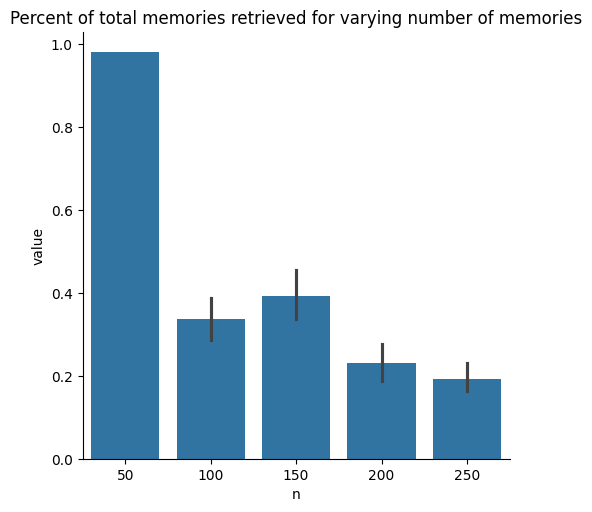

In [ ]:
data = []
groups = 10
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    for _ in range(i):
        rewards[_] = -10
    lengths = exp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying numbers of memories (number of groups constant)")
plt.show()

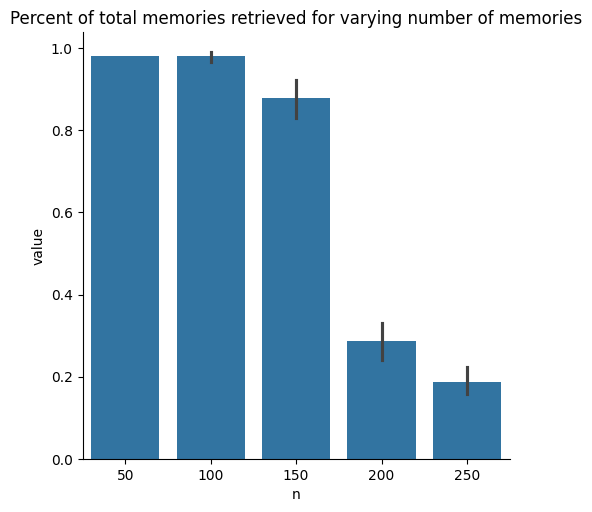

In [ ]:
data = []
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    groups = n // 10
    for _ in range(i):
        rewards[_] = -10
    lengths = exp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying number of memories (group size constant)")
plt.show()

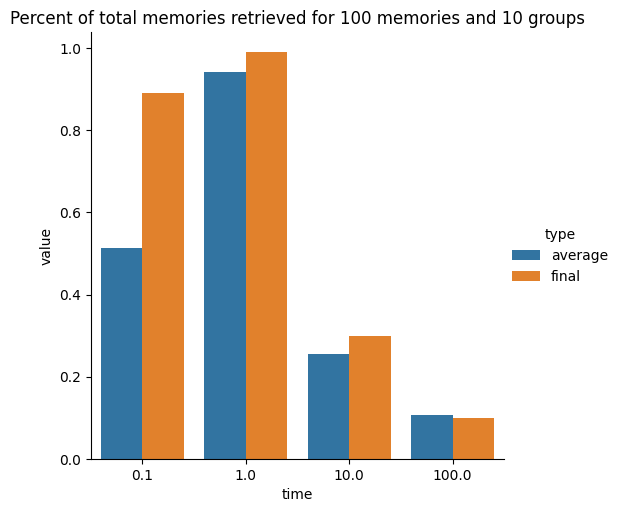

In [6]:
data = []
n = 100
groups = 10
for t in [0.1, 1, 10, 100]:
    avg, final = exp_2(n, groups, max_length=n - 1, time=t)
    data.append({"time": t, "type": "average", "value": avg / n})
    data.append({"time": t, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="time", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()

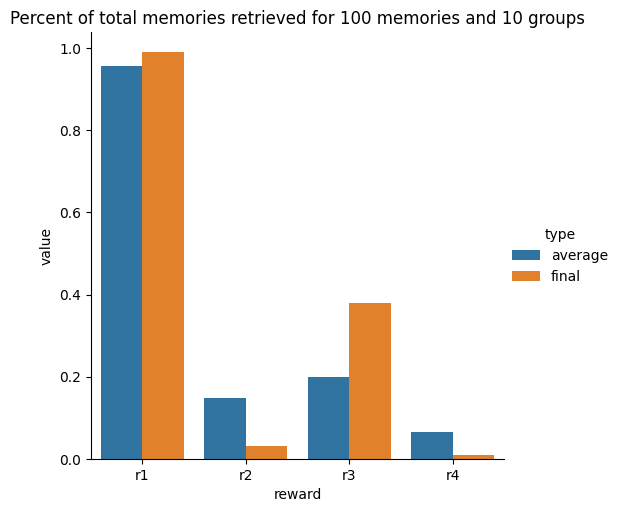

In [18]:
data = []
groups = 10
n = 100
rewards = {i: 1 for i in range(n)}
rewards1 = rewards.copy()
rewards2 = rewards.copy()
rewards3 = rewards.copy()
rewards4 = rewards.copy()
rewards1[0] = -10
rewards2[0] = -100
for i in range(5):
    rewards3[i] = -10
    rewards4[i] = -100
for r, name in zip([rewards1, rewards2, rewards3, rewards4], ["r1", "r2", "r3", "r4"]):
    avg, final = exp_2(n, groups, max_length=n - 1, time=0.1, rewards=r)
    data.append({"reward": name, "type": "average", "value": avg / n})
    data.append({"reward": name, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="reward", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()